# _Loan Eligibility Prediction_:

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Import Dataset 

In [2]:
df_original = pd.read_csv("loan_approval_dataset.csv")

df = df_original.copy()
df_original

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## Step 3: Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [5]:
print("Checking missing value:")
df.isnull().sum()

Checking missing value:


loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [6]:
print("Checking the duplicates:",df.duplicated().sum())

Checking the duplicates: 0


In [7]:
print(df.columns)

df.columns = df.columns.str.strip()
print("\nAfter removing the space:",df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

After removing the space: Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [8]:
cat_cols = ['education', 'self_employed']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()   # clean
    mode_val = df[col][df[col] != 'nan'].mode() # ignore 'nan' string
    
    if not mode_val.empty:
        df[col].fillna(mode_val[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_31288\3219932834.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val[0], inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_31288\3219932834.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [9]:
print(df[['education','self_employed']].isnull().sum())

education        0
self_employed    0
dtype: int64


## Step 4: Data Visualization

In [10]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

<Figure size 1000x400 with 0 Axes>

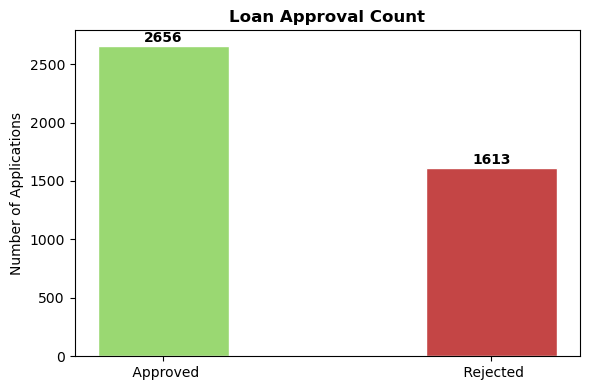

loan_status
Approved    62.22
Rejected    37.78
Name: count, dtype: float64


In [11]:
# Loan Status Distribution
plt.figure(figsize=(10,4))

# Colors
APPROVED = "#9AD872"
REJECTED = "#C44545"

counts = df["loan_status"].value_counts()
 
plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values,
               color=[APPROVED, REJECTED], width=0.4, edgecolor="white")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30, str(val),
             ha="center", fontweight="bold")
plt.title("Loan Approval Count", fontweight="bold")
plt.ylabel("Number of Applications")
plt.tight_layout()

plt.show()

percentages = (counts / counts.sum()) * 100
print(percentages.round(2))

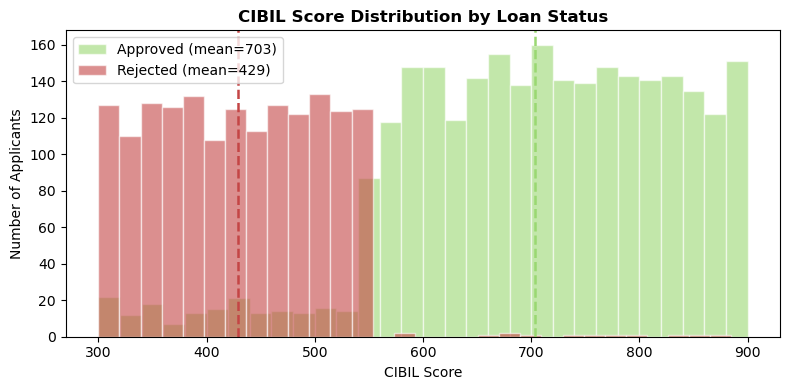

In [12]:
df['loan_status'] = df['loan_status'].str.strip()

plt.figure(figsize=(8, 4))
for status, color in zip(["Approved", "Rejected"], [APPROVED, REJECTED]):
    data = df[df["loan_status"] == status]["cibil_score"]
    plt.hist(data, bins=30, alpha=0.6, color=color,
             label=f"{status} (mean={data.mean():.0f})", edgecolor="white")
plt.axvline(df[df["loan_status"]=="Approved"]["cibil_score"].mean(),
            color=APPROVED, linestyle="--", linewidth=1.8)
plt.axvline(df[df["loan_status"]=="Rejected"]["cibil_score"].mean(),
            color=REJECTED, linestyle="--", linewidth=1.8)
plt.title("CIBIL Score Distribution by Loan Status", fontweight="bold")
plt.xlabel("CIBIL Score")
plt.ylabel("Number of Applicants")
plt.legend()
plt.tight_layout()

plt.show()

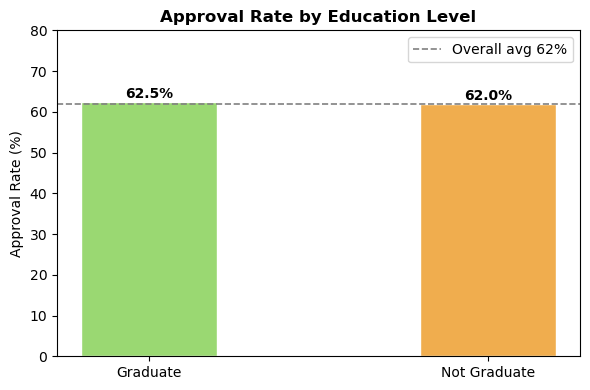

In [13]:
edu_rate = df.groupby("education")["loan_status"] \
             .apply(lambda x: (x == "Approved").mean() * 100)
 
plt.figure(figsize=(6, 4))
bars = plt.bar(edu_rate.index, edu_rate.values,
               color=[APPROVED, "#f0ad4e"], width=0.4, edgecolor="white")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{bar.get_height():.1f}%",
             ha="center", fontweight="bold")
plt.axhline(62, color="gray", linestyle="--", linewidth=1.2, label="Overall avg 62%")
plt.title("Approval Rate by Education Level", fontweight="bold")
plt.ylabel("Approval Rate (%)")
plt.ylim(0, 80)
plt.legend()
plt.tight_layout()

plt.show()

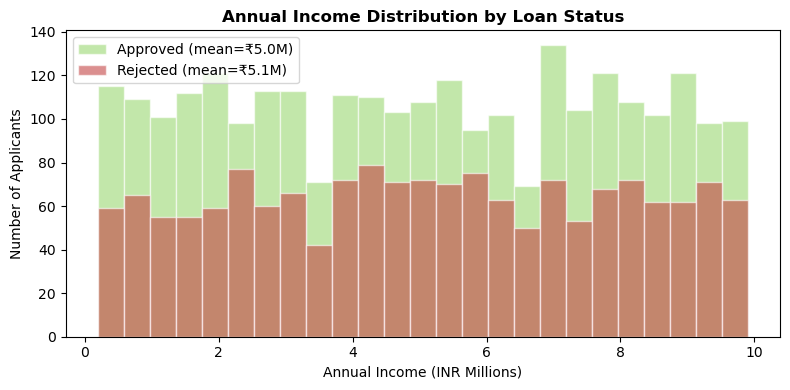

income_annum
7000000    62
4100000    59
7600000    57
4700000    56
5300000    55
           ..
3600000    33
3400000    33
9300000    33
8500000    32
6700000    30
Name: count, Length: 98, dtype: int64

In [14]:
plt.figure(figsize=(8, 4))
for status, color in zip(["Approved", "Rejected"], [APPROVED, REJECTED]):
    data = df[df["loan_status"] == status]["income_annum"] / 1e6
    plt.hist(data, bins=25, alpha=0.6, color=color,
             label=f"{status} (mean=₹{data.mean():.1f}M)", edgecolor="white")
plt.title("Annual Income Distribution by Loan Status", fontweight="bold")
plt.xlabel("Annual Income (INR Millions)")
plt.ylabel("Number of Applicants")
plt.legend()
plt.tight_layout()

plt.show()

df['income_annum'].value_counts()

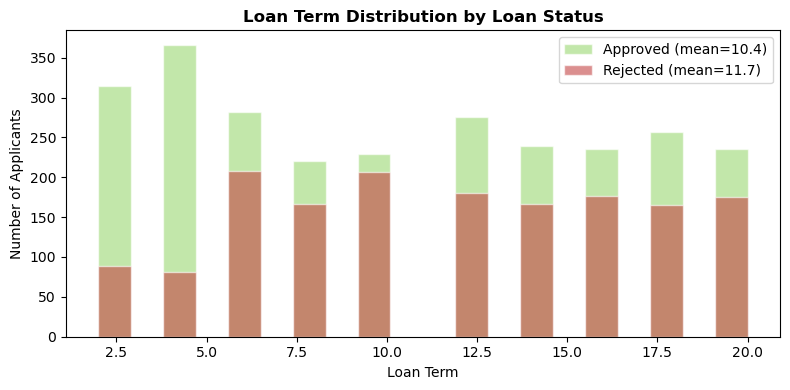

loan_term
6     490
12    456
4     447
10    436
18    422
16    412
20    411
14    405
2     404
8     386
Name: count, dtype: int64

In [15]:
plt.figure(figsize=(8, 4))
for status, color in zip(["Approved", "Rejected"], [APPROVED, REJECTED]):
    data = df[df["loan_status"] == status]["loan_term"]
    plt.hist(data, bins=20, alpha=0.6, color=color,
             label=f"{status} (mean={data.mean():.1f})", edgecolor="white")
plt.title("Loan Term Distribution by Loan Status", fontweight="bold")
plt.xlabel("Loan Term")
plt.ylabel("Number of Applicants")
plt.legend()
plt.tight_layout()

plt.show()

df['loan_term'].value_counts()

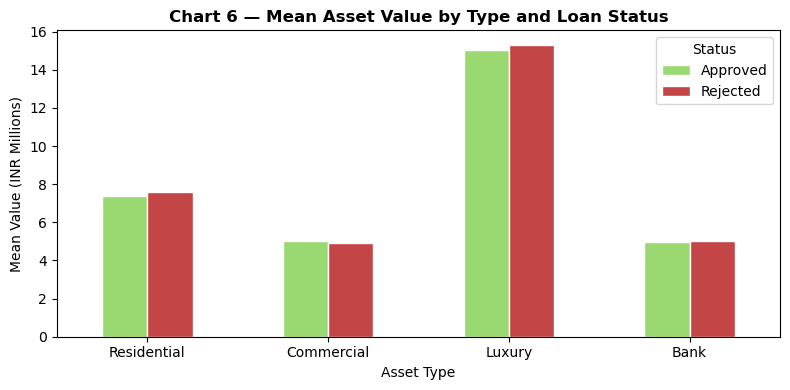

In [16]:
asset_means = df.groupby("loan_status")[[
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]].mean() / 1e6
 
asset_means.columns = ["Residential", "Commercial", "Luxury", "Bank"]
 
asset_means.T.plot(kind="bar", color=[APPROVED, REJECTED],
                   figsize=(8, 4), edgecolor="white", width=0.5, rot=0)
plt.title("Chart 6 — Mean Asset Value by Type and Loan Status", fontweight="bold")
plt.ylabel("Mean Value (INR Millions)")
plt.xlabel("Asset Type")
plt.legend(title="Status")
plt.tight_layout()

plt.show()

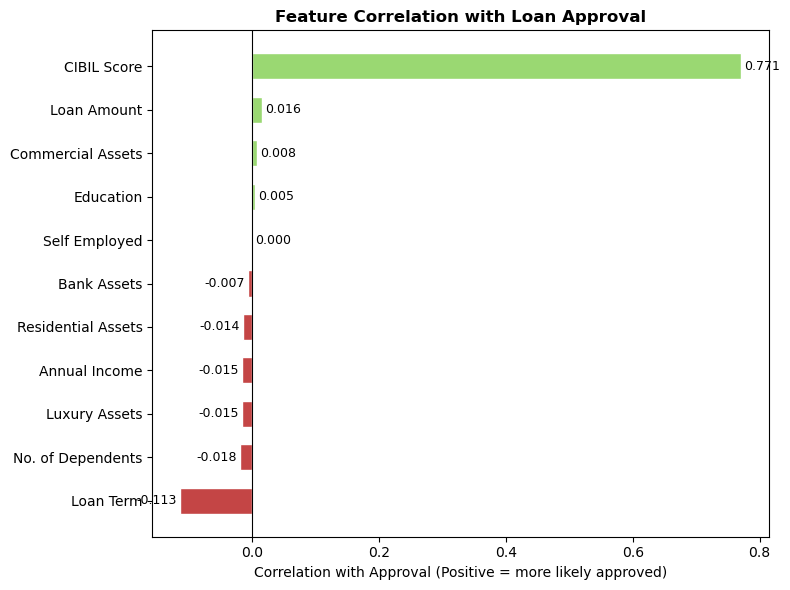

In [17]:
df["approved"] = (df["loan_status"] == "Approved").astype(int)
df["education_enc"] = (df["education"] == "Graduate").astype(int)
df["self_emp_enc"]  = (df["self_employed"] == "Yes").astype(int)
 
features = {
    "cibil_score":                "CIBIL Score",
    "loan_term":                  "Loan Term",
    "no_of_dependents":           "No. of Dependents",
    "income_annum":               "Annual Income",
    "loan_amount":                "Loan Amount",
    "residential_assets_value":   "Residential Assets",
    "commercial_assets_value":    "Commercial Assets",
    "luxury_assets_value":        "Luxury Assets",
    "bank_asset_value":           "Bank Assets",
    "education_enc":              "Education",
    "self_emp_enc":               "Self Employed",
}
 
corr = df[[*features.keys(), "approved"]].corr()["approved"].drop("approved")
corr.index = list(features.values())
corr = corr.sort_values()
 
colors = [APPROVED if v > 0 else REJECTED for v in corr.values]
 
plt.figure(figsize=(8, 6))
bars = plt.barh(corr.index, corr.values, color=colors, edgecolor="white", height=0.6)
plt.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr.values):
    plt.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center",
             ha="left" if val >= 0 else "right", fontsize=9)
plt.title("Feature Correlation with Loan Approval", fontweight="bold")
plt.xlabel("Correlation with Approval (Positive = more likely approved)")
plt.tight_layout()

plt.show()

In [18]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,approved,education_enc,self_emp_enc
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,1,1,0
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,0,0,1
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,0,1,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,0,1,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,0,0,1


In [19]:
df = df.drop(columns=['loan_id'])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,approved,education_enc,self_emp_enc
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,1,1,0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,0,0,1
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,0,1,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,0,1,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,0,0,1


## Step 5: Feature Engineering

In [20]:
categorical_col = df.select_dtypes(include=['object','category'])
print(categorical_col)

         education self_employed loan_status
0         Graduate            No    Approved
1     Not Graduate           Yes    Rejected
2         Graduate            No    Rejected
3         Graduate            No    Rejected
4     Not Graduate           Yes    Rejected
...            ...           ...         ...
4264      Graduate           Yes    Rejected
4265  Not Graduate           Yes    Approved
4266  Not Graduate            No    Rejected
4267  Not Graduate            No    Approved
4268      Graduate            No    Approved

[4269 rows x 3 columns]


In [21]:
#ENCODE CATEGORICAL VARIABLES
df['education'] = df['education'].map({'Graduate':1, 'Not Graduate':0})
df['self_employed'] = df['self_employed'].map({'Yes':1, 'No':0})
df['loan_status'] = df['loan_status'].map({'Approved':1, 'Rejected':0})

In [22]:
#Debt-to-Income Ratio
df['debt_to_income'] = df['loan_amount'] / df['income_annum']

In [23]:
#Total Assets
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)

In [24]:
#Loan per Term
df['loan_per_term'] = df['loan_amount'] / df['loan_term']

In [25]:
#Income per Dependent
df['income_per_dependent'] = df['income_annum'] / (df['no_of_dependents'] + 1)

In [26]:
#Asset to Loan Ratio
df['asset_loan_ratio'] = df['total_assets'] / df['loan_amount']

In [27]:
df = df.drop(columns=['approved', 'education_enc', 'self_emp_enc'])

In [45]:
df = df.rename(columns = {'cibil_score':'credit_score'})

In [46]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,credit_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,debt_to_income,total_assets,loan_per_term,income_per_dependent,asset_loan_ratio
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.114583,50700000,2.491667e+06,3.200000e+06,1.695652
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.975610,17000000,1.525000e+06,4.100000e+06,1.393443
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.263736,57700000,1.485000e+06,2.275000e+06,1.942761
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.743902,52700000,3.837500e+06,2.050000e+06,1.716612
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.469388,55000000,1.210000e+06,1.633333e+06,2.272727


**Final Features**

In [47]:
X = df[['credit_score', 'income_annum', 'loan_amount', 'loan_term']]
y = df['loan_status']

### Splitting the dataset

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

Train size: (3415, 4)
Test size: (854, 4)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train scaled:",X_train_scaled)
print("Test scaled:",X_test_scaled)

Train scaled: [[-0.18740061  1.00950021  1.62477248 -0.86000338]
 [ 0.63739678  1.61417128  2.07712843  0.1888936 ]
 [ 0.47476068 -1.51589075 -1.35415691 -0.51037106]
 ...
 [-0.87860405  1.25848241  0.5986968   0.88815826]
 [-0.34422828  0.68938023  0.68696138  0.1888936 ]
 [ 1.37506769  0.40482913  0.23460543 -0.86000338]]
Test scaled: [[-1.02962329  0.12027804  0.49939915  1.58742291]
 [-0.00733921  0.29812247 -0.12948594 -0.51037106]
 [-0.86117876  1.61417128  0.5214653   0.53852593]
 ...
 [ 0.5502703   0.19141581 -0.40531274 -1.20963571]
 [-1.32004491 -1.01792634 -0.72527182  1.58742291]
 [-0.44878006 -0.76894413 -0.6921726  -0.86000338]]


## Step 6: Model Evaluation

### Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

#Train Model
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [51]:
#Predict the model
pred = model.predict(X_test_scaled)

## Step 7: Evaluation Metrics

In [52]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

acc = accuracy_score(y_test,pred)
print(f"Model Accuracy:{acc*100:.2f}%")

Model Accuracy:90.52%


In [53]:
print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=["Rejected", "Approved"]))


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.88      0.87      0.87       318
    Approved       0.92      0.93      0.92       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.91       854



In [54]:
print("\nConfusion matrix:")
print(confusion_matrix(y_test,pred))


Confusion matrix:
[[276  42]
 [ 39 497]]


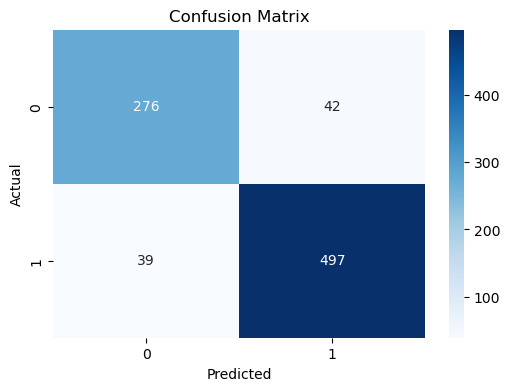

In [55]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [56]:
def predict_loan(
    no_of_dependents,
    education,
    self_employed,
    income_annum,
    loan_amount,
    loan_term,
    cibil_score,
    residential_assets_value,
    commercial_assets_value,
    luxury_assets_value,
    bank_asset_value
):
    import pandas as pd

    # Encode
    education = 1 if education == "Graduate" else 0
    self_employed = 1 if self_employed == "Yes" else 0

    # Feature engineering
    total_assets = (
        residential_assets_value +
        commercial_assets_value +
        luxury_assets_value +
        bank_asset_value
    )

    debt_to_income = loan_amount / income_annum
    loan_per_term = loan_amount / loan_term
    income_per_dependent = income_annum / (no_of_dependents + 1)
    asset_loan_ratio = total_assets / loan_amount

    # Create dictionary (IMPORTANT)
    input_dict = {
        'no_of_dependents': no_of_dependents,
        'education': education,
        'self_employed': self_employed,
        'income_annum': income_annum,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'residential_assets_value': residential_assets_value,
        'commercial_assets_value': commercial_assets_value,
        'luxury_assets_value': luxury_assets_value,
        'bank_asset_value': bank_asset_value,
        'total_assets': total_assets,
        'debt_to_income': debt_to_income,
        'loan_per_term': loan_per_term,
        'income_per_dependent': income_per_dependent,
        'asset_loan_ratio': asset_loan_ratio
    }

    # Convert to DataFrame
    input_df = pd.DataFrame([input_dict])

    # Align columns with training data
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)[0]
    print("Raw prediction:", prediction)

    return "Approved" if prediction == 1 else "Rejected"

In [57]:
result = predict_loan(
    1, "Graduate", "No",
    800000, 200000, 12, 750,
    300000, 200000, 100000, 150000
)

print("Loan Status:", result)

Raw prediction: 0
Loan Status: Rejected


In [58]:
result = predict_loan(
    4, "Not Graduate", "Yes",
    150000, 500000, 6, 500,
    50000, 20000, 10000, 10000
)

print("Loan Status:", result)

Raw prediction: 0
Loan Status: Rejected


In [59]:
import pickle
 
# Save the Logistic Regression model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
 
# Save the StandardScaler (fitted on training data)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
 
print("model.pkl saved")
print("scaler.pkl saved")
print("Both files are now in the same folder as your notebook.")

model.pkl saved
scaler.pkl saved
Both files are now in the same folder as your notebook.


In [60]:
import pickle

# Save feature column names
feature_columns = X.columns.tolist()

with open("columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("columns.pkl saved")

columns.pkl saved
